# Natural Language Processing
## Tickets classification 

In [22]:
#Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import re
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


### Dataset

https://www.kaggle.com/datasets/adisongoh/it-service-ticket-classification-dataset

In [43]:
df = pd.read_csv('all_tickets_processed_improved_v3.csv')
df = df[['Topic_group','Document']]
df = df.rename(columns={"Topic_group": "Category", "Document": "Content"})
df.head(20)

,Category,Content
0,Hardware,connection with icon icon dear please setup ic...
1,Access,work experience user work experience user hi w...
2,Hardware,requesting for meeting requesting meeting hi p...
3,Access,reset passwords for external accounts re expir...
4,Miscellaneous,mail verification warning hi has got attached ...
5,Miscellaneous,mail please dear looks blacklisted receiving m...
6,Hardware,prod servers tunneling prod tunneling va la tu...
7,HR Support,access request dear modules report report cost...
8,Access,reset passwords for our client and passwords c...
9,HR Support,direct reports missing time please action repo...


In [19]:
def clean_text(text):
    text = text.lower()

    # eliminar emails
    text = re.sub(r'\S+@\S+', '', text)

    # eliminar URLs
    text = re.sub(r'http\S+', '', text)

    # eliminar números
    text = re.sub(r'\d+', '', text)

    # eliminar caracteres especiales
    text = re.sub(r'[^a-z\s]', ' ', text)

    # eliminar espacios múltiples
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['Document'] = df['Document'].apply(clean_text)

In [20]:
X = df['Document']
y = df['Topic_group']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Train

In [27]:

model = Pipeline([
    ("tfidf", TfidfVectorizer(lowercase=True, stop_words="english", max_features=20000, ngram_range=(1,2), min_df=3)),
    ("clf", LogisticRegression(max_iter=200, n_jobs=-1))
])

model.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


### Predict

In [28]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

                       precision    recall  f1-score   support

               Access       0.92      0.87      0.90      1455
Administrative rights       0.88      0.66      0.76       342
           HR Support       0.85      0.84      0.85      2107
             Hardware       0.79      0.89      0.84      2760
     Internal Project       0.91      0.77      0.84       451
        Miscellaneous       0.81      0.82      0.82      1400
             Purchase       0.98      0.87      0.92       497
              Storage       0.95      0.84      0.89       556

             accuracy                           0.85      9568
            macro avg       0.89      0.82      0.85      9568
         weighted avg       0.85      0.85      0.85      9568



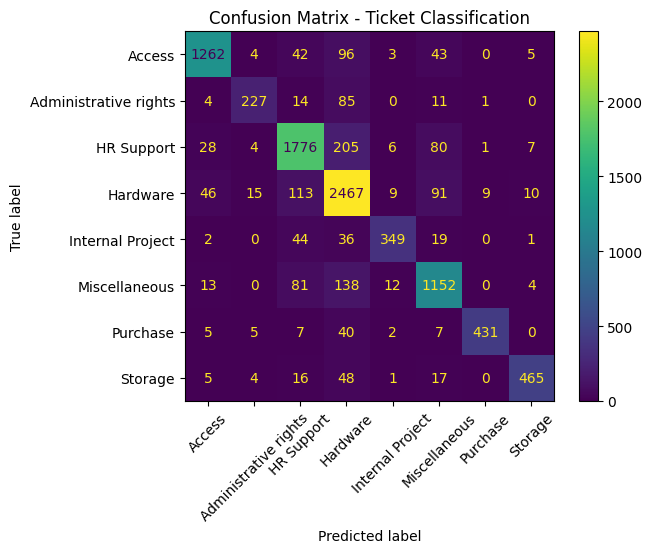

In [29]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix - Ticket Classification")
plt.show()

In [ ]:
sample_tickets = [
    "I cannot login to my company email account since this morning. The system says password invalid.",
    "Request to install Microsoft Visio software on my workstation for the architecture team.",
    "VPN connection keeps dropping every 5 minutes when working from home.",
    "Need access to the shared finance folder for the new project starting next week.",
    "Laptop is overheating and shutting down after a few minutes of use."
]
sample_tickets = [clean_text(ticket) for ticket in sample_tickets]
sample_tickets = sample_tickets*5000

predictions = model.predict(sample_tickets)

df_predictions = pd.DataFrame({
    "Ticket": sample_tickets,
    "Prediction": predictions
})

In [41]:
df_predictions

,Ticket,Prediction
0,i cannot login to my company email account sin...,Access
1,request to install microsoft visio software on...,Administrative rights
2,vpn connection keeps dropping every minutes wh...,Hardware
3,need access to the shared finance folder for t...,Storage
4,laptop is overheating and shutting down after ...,Hardware
...,...,...
24995,i cannot login to my company email account sin...,Access
24996,request to install microsoft visio software on...,Administrative rights
24997,vpn connection keeps dropping every minutes wh...,Hardware
24998,need access to the shared finance folder for t...,Storage
